In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Data Loading

In [2]:
X_train_resampled = pd.read_csv("Data/X_train_resampled.csv")
y_train_resampled = pd.read_csv("Data/y_train_resampled.csv").squeeze()
X_val_scaled = pd.read_csv("Data/X_val_scaled.csv")
y_val = pd.read_csv("Data/y_val.csv").squeeze()
X_test_scaled = pd.read_csv("Data/X_test_scaled.csv")
y_test = pd.read_csv("Data/y_test.csv").squeeze()
print("Loaded preprocessed splits.")

Loaded preprocessed splits.


## Linear SVM: Tuning and Training

`LinearSVC` is used instead of `SVC(kernel='rbf')` for scalability, since it's equivalent to a linear kernel SVM but uses liblinear under the hood, which handles large datasets more efficiently

`CalibratedClassifierCV` wraps it to produce probability estimates (which is needed for AUC-ROC).

In [3]:
svm_param_grid = {
    'estimator__C': [0.01, 0.1, 1, 10]
}

svm_base = CalibratedClassifierCV(
    LinearSVC(random_state=RANDOM_STATE, max_iter=2000)
)

svm_grid = GridSearchCV(
    svm_base,
    svm_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {svm_grid.best_params_}")
print(f"Best CV AUC: {svm_grid.best_score_:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'estimator__C': 0.01}
Best CV AUC: 0.8434


## Linear SVM: Validation Results

In [4]:
svm_best = svm_grid.best_estimator_

svm_val_preds = svm_best.predict(X_val_scaled)
svm_val_probs = svm_best.predict_proba(X_val_scaled)[:, 1]

print("=== Linear SVM — Validation Set Results ===\n")
print(classification_report(y_val, svm_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, svm_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, svm_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, svm_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, svm_val_preds):.4f}")
print(svm_grid.best_params_)

=== Linear SVM — Validation Set Results ===

               precision    recall  f1-score   support

        No HD       0.97      0.74      0.84     30910
Heart Disease       0.25      0.77      0.38      3557

     accuracy                           0.74     34467
    macro avg       0.61      0.76      0.61     34467
 weighted avg       0.89      0.74      0.79     34467

AUC-ROC:   0.8349
F1:        0.3829
Precision: 0.2549
Recall:    0.7695
{'estimator__C': 0.01}


## Linear SVM: Confusion Matrix

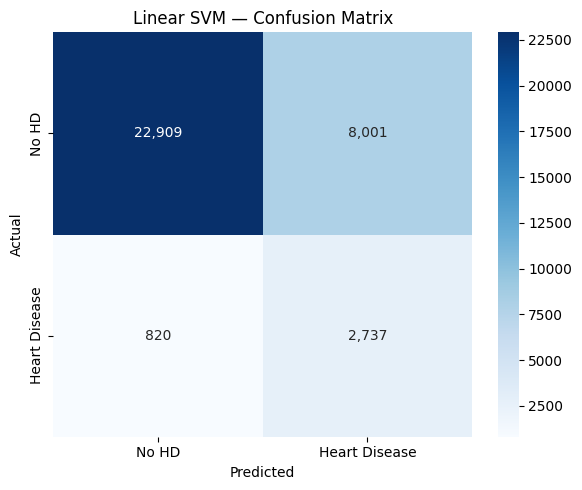

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, svm_val_preds)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Linear SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

## Linear SVM: ROC Curve

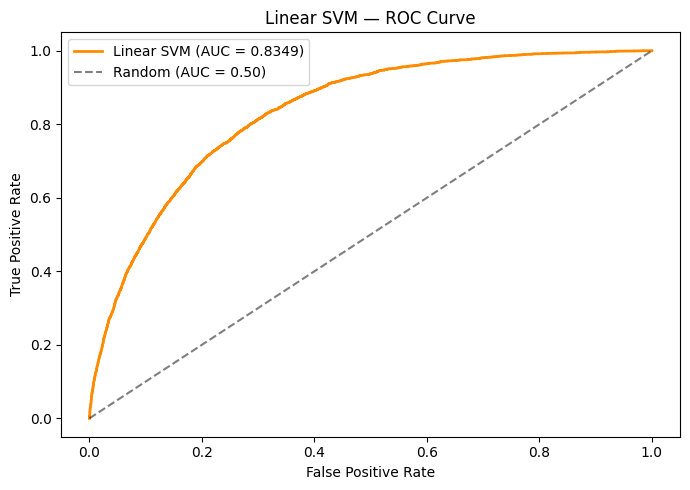

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
svm_fpr, svm_tpr, _ = roc_curve(y_val, svm_val_probs)
svm_auc = roc_auc_score(y_val, svm_val_probs)
ax.plot(svm_fpr, svm_tpr, color='darkorange', lw=2, label=f'Linear SVM (AUC = {svm_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Linear SVM — ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Gaussian Naive Bayes: Tuning and Training

In [7]:
nb_param_grid = {
    'var_smoothing': np.logspace(-12, 0, 13)
}

nb_base = GaussianNB()

nb_grid = GridSearchCV(
    nb_base,
    nb_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {nb_grid.best_params_}")
print(f"Best CV AUC: {nb_grid.best_score_:.4f}")

Fitting 3 folds for each of 13 candidates, totalling 39 fits
Best params: {'var_smoothing': np.float64(1.0)}
Best CV AUC: 0.8085


## Gaussian Naive Bayes: Validation Results

In [8]:
nb_best = nb_grid.best_estimator_

nb_val_preds = nb_best.predict(X_val_scaled)
nb_val_probs = nb_best.predict_proba(X_val_scaled)[:, 1]

print("=== Gaussian Naive Bayes — Validation Set Results ===\n")
print(classification_report(y_val, nb_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, nb_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, nb_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, nb_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, nb_val_preds):.4f}")
print(nb_grid.best_params_)

=== Gaussian Naive Bayes — Validation Set Results ===

               precision    recall  f1-score   support

        No HD       0.95      0.79      0.86     30910
Heart Disease       0.26      0.65      0.37      3557

     accuracy                           0.78     34467
    macro avg       0.61      0.72      0.62     34467
 weighted avg       0.88      0.78      0.81     34467

AUC-ROC:   0.8082
F1:        0.3720
Precision: 0.2613
Recall:    0.6458
{'var_smoothing': np.float64(1.0)}


## Gaussian Naive Bayes: Confusion Matrix

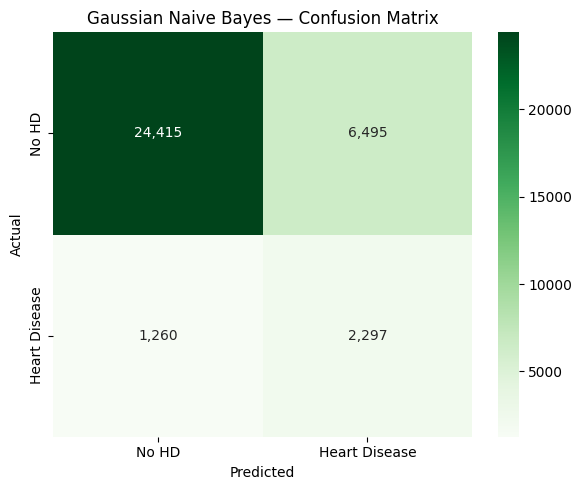

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, nb_val_preds)
sns.heatmap(cm, annot=True, fmt=',', cmap='Greens', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Gaussian Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.show()

## Gaussian Naive Bayes: ROC Curve

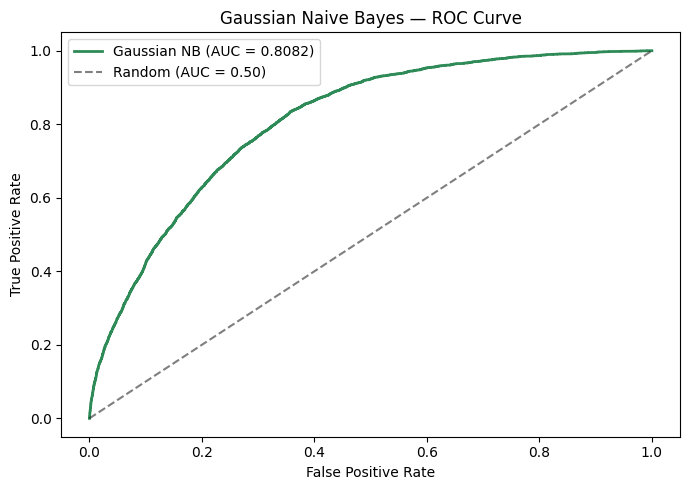

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
nb_fpr, nb_tpr, _ = roc_curve(y_val, nb_val_probs)
nb_auc = roc_auc_score(y_val, nb_val_probs)
ax.plot(nb_fpr, nb_tpr, color='seagreen', lw=2, label=f'Gaussian NB (AUC = {nb_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Gaussian Naive Bayes — ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Model Comparison: Linear SVM vs. Gaussian Naive Bayes

             AUC-ROC  F1 (HD)  Precision (HD)  Recall (HD)
Model                                                     
Linear SVM    0.8349   0.3829          0.2549       0.7695
Gaussian NB   0.8082   0.3720          0.2613       0.6458


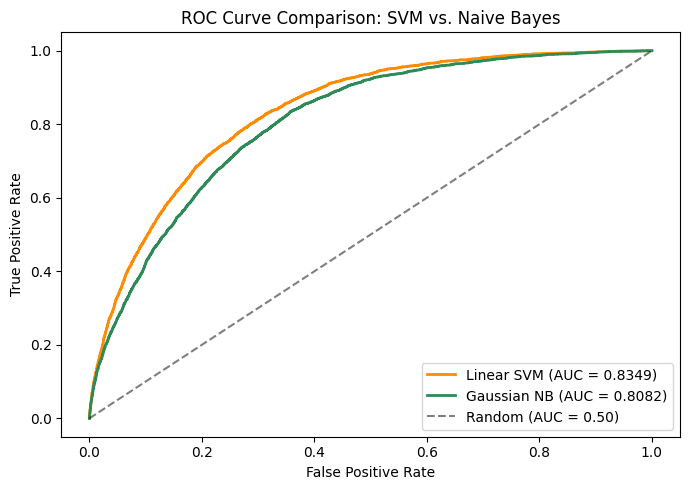

In [11]:
comparison = pd.DataFrame({
    'Model': ['Linear SVM', 'Gaussian NB'],
    'AUC-ROC': [
        roc_auc_score(y_val, svm_val_probs),
        roc_auc_score(y_val, nb_val_probs)
    ],
    'F1 (HD)': [
        f1_score(y_val, svm_val_preds),
        f1_score(y_val, nb_val_preds)
    ],
    'Precision (HD)': [
        precision_score(y_val, svm_val_preds),
        precision_score(y_val, nb_val_preds)
    ],
    'Recall (HD)': [
        recall_score(y_val, svm_val_preds),
        recall_score(y_val, nb_val_preds)
    ]
}).set_index('Model').round(4)

print(comparison.to_string())

# Overlay ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(svm_fpr, svm_tpr, color='darkorange', lw=2, label=f'Linear SVM (AUC = {svm_auc:.4f})')
ax.plot(nb_fpr, nb_tpr, color='seagreen', lw=2, label=f'Gaussian NB (AUC = {nb_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison: SVM vs. Naive Bayes')
ax.legend()
plt.tight_layout()
plt.show()

## Linear SVM: Final Test Set Evaluation

In [12]:
svm_test_preds = svm_best.predict(X_test_scaled)
svm_test_probs = svm_best.predict_proba(X_test_scaled)[:, 1]

print("=== Linear SVM — Test Set Results ===\n")
print(classification_report(y_test, svm_test_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_test, svm_test_probs):.4f}")
print(f"F1:        {f1_score(y_test, svm_test_preds):.4f}")
print(f"Precision: {precision_score(y_test, svm_test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, svm_test_preds):.4f}")

=== Linear SVM — Test Set Results ===

               precision    recall  f1-score   support

        No HD       0.97      0.74      0.84     30910
Heart Disease       0.26      0.79      0.39      3558

     accuracy                           0.74     34468
    macro avg       0.61      0.76      0.61     34468
 weighted avg       0.89      0.74      0.79     34468

AUC-ROC:   0.8375
F1:        0.3872
Precision: 0.2569
Recall:    0.7858


## Gaussian Naive Bayes: Final Test Set Evaluation

In [13]:
nb_test_preds = nb_best.predict(X_test_scaled)
nb_test_probs = nb_best.predict_proba(X_test_scaled)[:, 1]

print("=== Gaussian Naive Bayes — Test Set Results ===\n")
print(classification_report(y_test, nb_test_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_test, nb_test_probs):.4f}")
print(f"F1:        {f1_score(y_test, nb_test_preds):.4f}")
print(f"Precision: {precision_score(y_test, nb_test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, nb_test_preds):.4f}")

=== Gaussian Naive Bayes — Test Set Results ===

               precision    recall  f1-score   support

        No HD       0.95      0.79      0.86     30910
Heart Disease       0.26      0.65      0.37      3558

     accuracy                           0.78     34468
    macro avg       0.61      0.72      0.62     34468
 weighted avg       0.88      0.78      0.81     34468

AUC-ROC:   0.8081
F1:        0.3749
Precision: 0.2637
Recall:    0.6487


## Observations

### Linear SVM

- Best regularization was `C=0.01`, meaning strong regularization worked best -- same as logistic regression.
- AUC-ROC was 0.8349, nearly identical to logistic regression (0.8351). The two models are almost indistinguishable in terms of ranking ability.
- Recall for heart disease was 0.77, also matching logistic regression closely.
- Precision for heart disease was 0.25, again the same as logistic regression.
- This makes sense: both are linear classifiers finding a decision boundary in the same feature space. With SMOTE balancing, they converge to similar behavior.

### Gaussian Naive Bayes

- Best `var_smoothing` was 1.0, which is very high. This suggests the model needed heavy smoothing, likely because many features in this dataset are not well-approximated by a Gaussian distribution (several are binary).
- AUC-ROC was 0.8082, lower than both logistic regression (0.8351) and SVM (0.8349).
- Recall for heart disease was 0.65, noticeably lower than LR and SVM (both ~0.77). The model is more conservative about predicting heart disease.
- Precision was 0.26, slightly better than LR and SVM (0.25), but the difference is negligible.
- The independence assumption in Naive Bayes likely hurts here since health-related features are correlated (e.g., high blood pressure and diabetes tend to co-occur).

### Comparison Against Logistic Regression

| Model | AUC-ROC | F1 | Precision | Recall |
|---|---|---|---|---|
| Logistic Regression | 0.8351 | 0.3826 | 0.2547 | 0.7689 |
| Linear SVM | 0.8349 | 0.3829 | 0.2549 | 0.7695 |
| Gaussian NB | 0.8082 | 0.3720 | 0.2613 | 0.6458 |

- Logistic regression and linear SVM are essentially tied across all metrics. This is expected since they are both linear models optimizing similar objectives.
- Naive Bayes trails behind in AUC-ROC and recall, making it the weakest of the three.
- For a medical screening task where missing positive cases is costly, logistic regression and SVM are both better choices than Naive Bayes due to their higher recall.